In [ ]:
import pandas as pd

In [ ]:
df5=pd.read_csv('https://raw.githubusercontent.com/Taj1920/Data-Analysis-Datasets/refs/heads/main/Datasets-Cleaning/laptopData.csv')


In [ ]:
df5.drop('Unnamed: 0',axis=1,inplace=True)


In [ ]:
df5.drop_duplicates(inplace=True)


In [ ]:
df5.dropna(inplace=True)


In [ ]:
data=[ i.split()[0] for i in df5['Cpu']]
df5['Processor']=data


In [ ]:
data3=[i.split()[0] for i in df5['Memory']]
# ---->Capacity

df5['Capacity']=data3

In [ ]:
data4=[i.split()[-1] for i in df5['Memory']]
df5['Storage']=data4
df5['Storage'].str.replace('Storage','Flash Storage')

,Storage
0,SSD
1,Flash Storage
2,SSD
3,SSD
4,SSD
...,...
1269,HDD
1270,SSD
1271,SSD
1272,Flash Storage


In [ ]:
df5.drop('ScreenResolution',axis=1,inplace=True)
df5.drop('Cpu',axis=1,inplace=True)
df5.drop('Memory',axis=1,inplace=True)
df5.drop('Gpu',axis=1,inplace=True)

In [ ]:
df5

,Company,TypeName,Inches,Ram,OpSys,Weight,Price,Processor,Capacity,Storage
0,Apple,Ultrabook,13.3,8GB,macOS,1.37kg,71378.6832,Intel,128GB,SSD
1,Apple,Ultrabook,13.3,8GB,macOS,1.34kg,47895.5232,Intel,128GB,Storage
2,HP,Notebook,15.6,8GB,No OS,1.86kg,30636.0000,Intel,256GB,SSD
3,Apple,Ultrabook,15.4,16GB,macOS,1.83kg,135195.3360,Intel,512GB,SSD
4,Apple,Ultrabook,13.3,8GB,macOS,1.37kg,96095.8080,Intel,256GB,SSD
...,...,...,...,...,...,...,...,...,...,...
1269,Asus,Notebook,15.6,4GB,Windows 10,2.2kg,38378.6496,Intel,500GB,HDD
1270,Lenovo,2 in 1 Convertible,14,4GB,Windows 10,1.8kg,33992.6400,Intel,128GB,SSD
1271,Lenovo,2 in 1 Convertible,13.3,16GB,Windows 10,1.3kg,79866.7200,Intel,512GB,SSD
1272,Lenovo,Notebook,14,2GB,Windows 10,1.5kg,12201.1200,Intel,64GB,Storage


In [ ]:
# visulizaion with seaborn



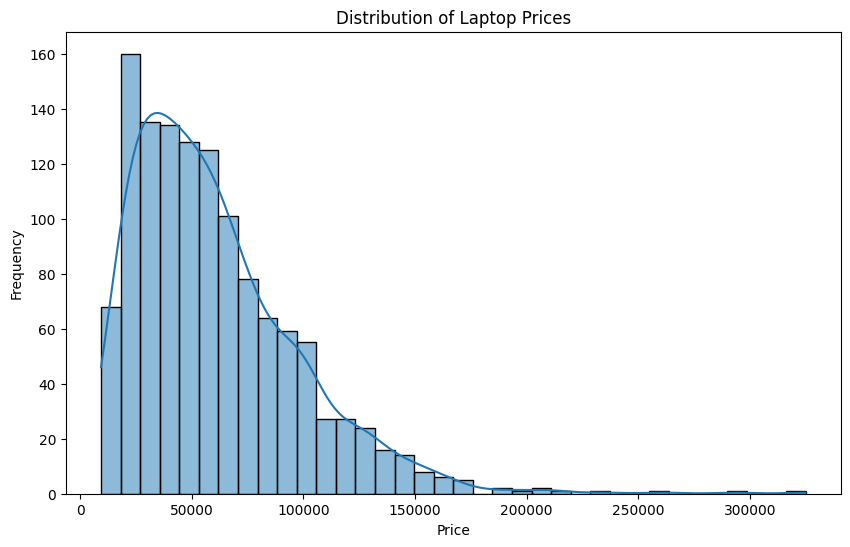

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Laptop Prices
if 'df5' not in locals() and 'df5' not in globals():
    print("Error: DataFrame 'df5' is not defined. Please ensure the preceding data loading and preprocessing cells are executed before running this visualization.")
else:
    plt.figure(figsize=(10, 6))
    sns.histplot(df5['Price'], kde=True)
    plt.title('Distribution of Laptop Prices')
    plt.xlabel('Price')
    plt.ylabel('Frequency')
    plt.show()

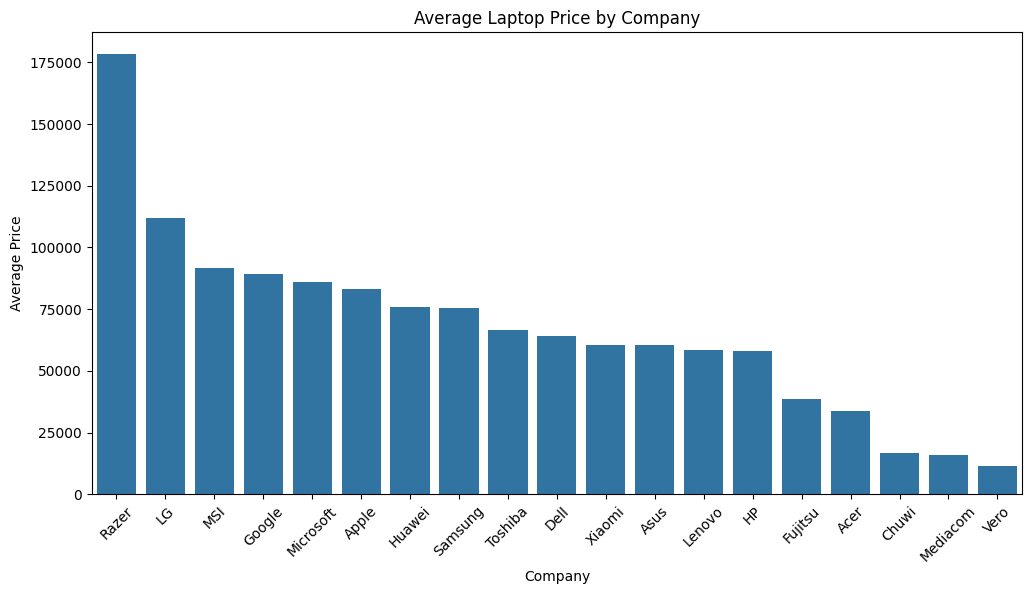

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Average Price by Company
if 'df5' not in locals() and 'df5' not in globals():
    print("Error: DataFrame 'df5' is not defined. Please ensure the preceding data loading and preprocessing cells are executed before running this visualization.")
else:
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Company', y='Price', data=df5.groupby('Company')['Price'].mean().reset_index().sort_values(by='Price', ascending=False))
    plt.title('Average Laptop Price by Company')
    plt.xlabel('Company')
    plt.ylabel('Average Price')
    plt.xticks(rotation=45)
    plt.show()

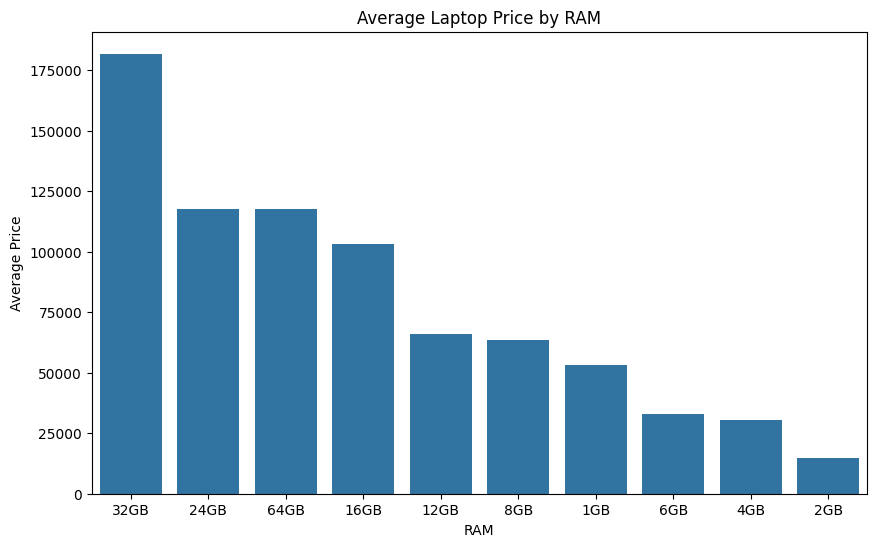

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Average Price by RAM
if 'df5' not in locals() and 'df5' not in globals():
    print("Error: DataFrame 'df5' is not defined. Please ensure the preceding data loading and preprocessing cells are executed before running this visualization.")
else:
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Ram', y='Price', data=df5.groupby('Ram')['Price'].mean().reset_index().sort_values(by='Price', ascending=False))
    plt.title('Average Laptop Price by RAM')
    plt.xlabel('RAM')
    plt.ylabel('Average Price')
    plt.show()

### Scatter Plot: Price vs. Weight

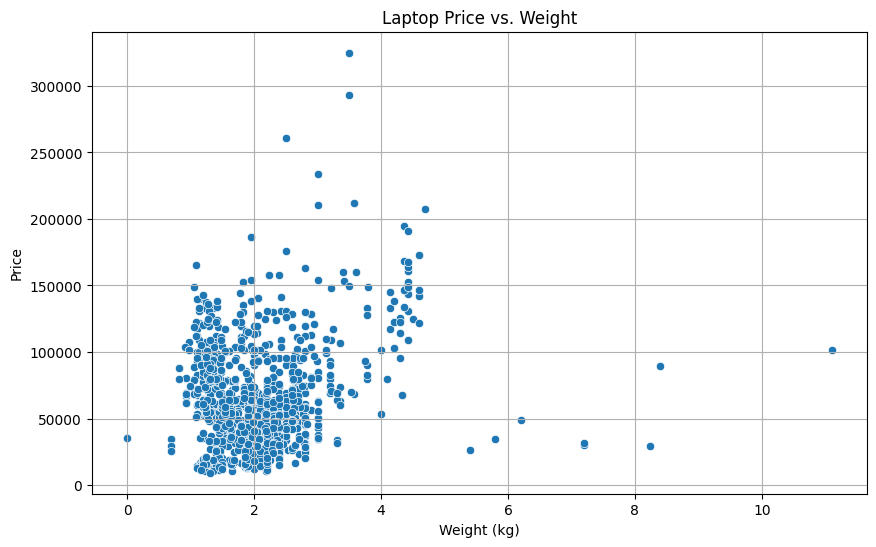

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convert 'Weight' to a numerical format for plotting if it's not already
df5_cleaned = df5.copy()
df5_cleaned['Weight_kg'] = df5_cleaned['Weight'].str.replace('kg', '', regex=False).replace('?', np.nan).astype(float)

# Drop rows where 'Weight_kg' is NaN after cleaning
df5_cleaned.dropna(subset=['Weight_kg'], inplace=True)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Weight_kg', y='Price', data=df5_cleaned)
plt.title('Laptop Price vs. Weight')
plt.xlabel('Weight (kg)')
plt.ylabel('Price')
plt.grid(True)
plt.show()

### Violin Plot: Price Distribution by Company

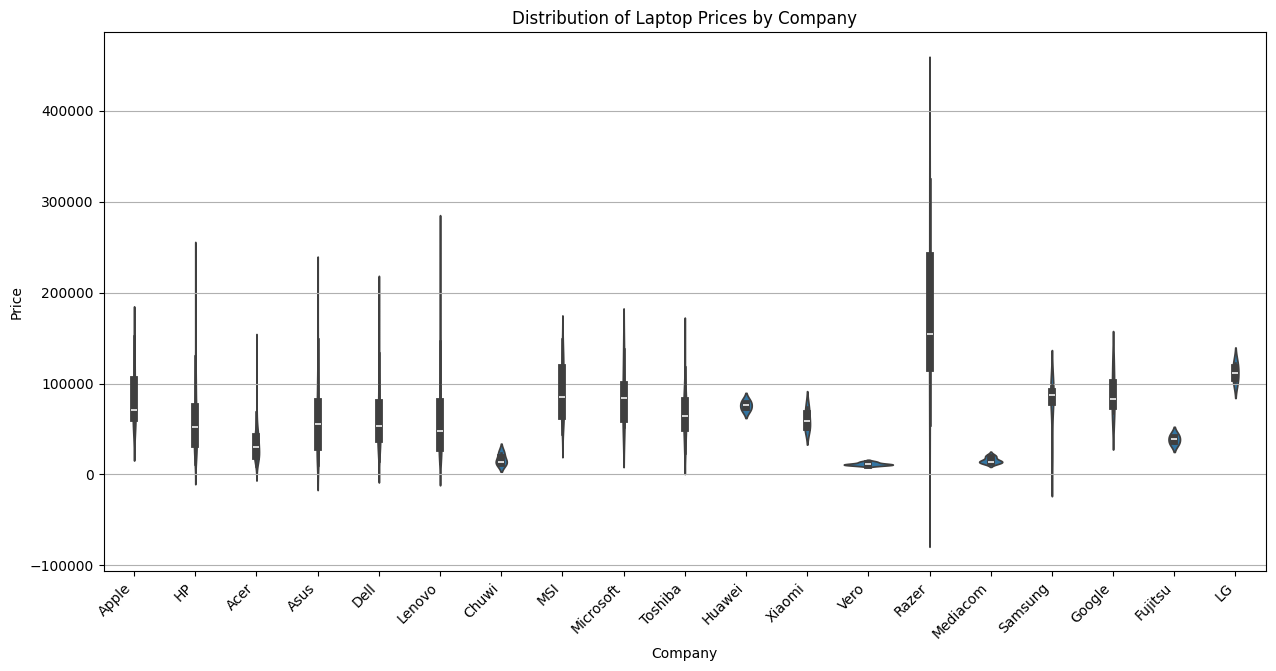

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 7))
sns.violinplot(x='Company', y='Price', data=df5)
plt.title('Distribution of Laptop Prices by Company')
plt.xlabel('Company')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()

### Pie Chart: Operating System Distribution

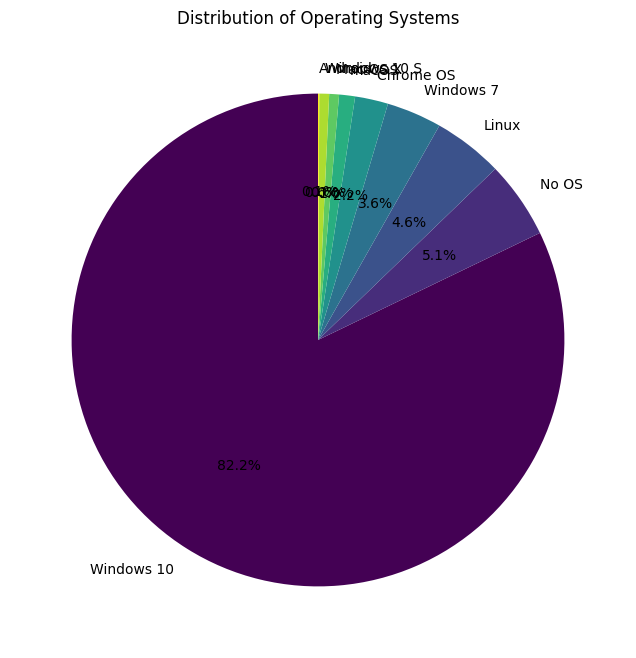

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
df5['OpSys'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title('Distribution of Operating Systems')
plt.ylabel('') # Hide the default 'OpSys' label
plt.show()

### Line Chart: Average Price by Inches (Screen Size)

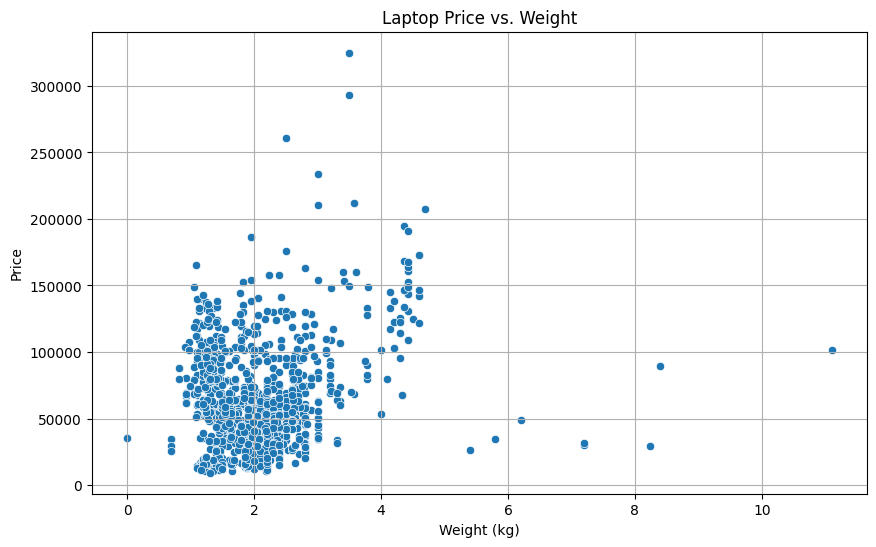

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convert 'Weight' to a numerical format for plotting if it's not already
df5_cleaned = df5.copy()
df5_cleaned['Weight_kg'] = df5_cleaned['Weight'].str.replace('kg', '', regex=False).replace('?', np.nan).astype(float)

# Drop rows where 'Weight_kg' is NaN after cleaning
df5_cleaned.dropna(subset=['Weight_kg'], inplace=True)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Weight_kg', y='Price', data=df5_cleaned)
plt.title('Laptop Price vs. Weight')
plt.xlabel('Weight (kg)')
plt.ylabel('Price')
plt.grid(True)
plt.show()

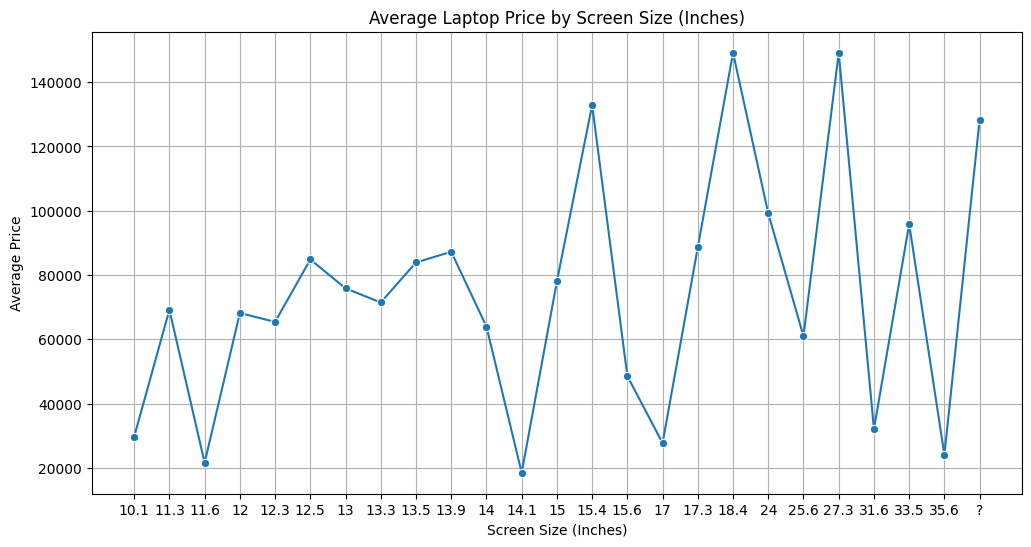

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Inches and calculate the mean Price, then sort by Inches for a meaningful line chart
avg_price_by_inches = df5.groupby('Inches')['Price'].mean().reset_index().sort_values(by='Inches')

plt.figure(figsize=(12, 6))
sns.lineplot(x='Inches', y='Price', data=avg_price_by_inches, marker='o')
plt.title('Average Laptop Price by Screen Size (Inches)')
plt.xlabel('Screen Size (Inches)')
plt.ylabel('Average Price')
plt.grid(True)
plt.show()

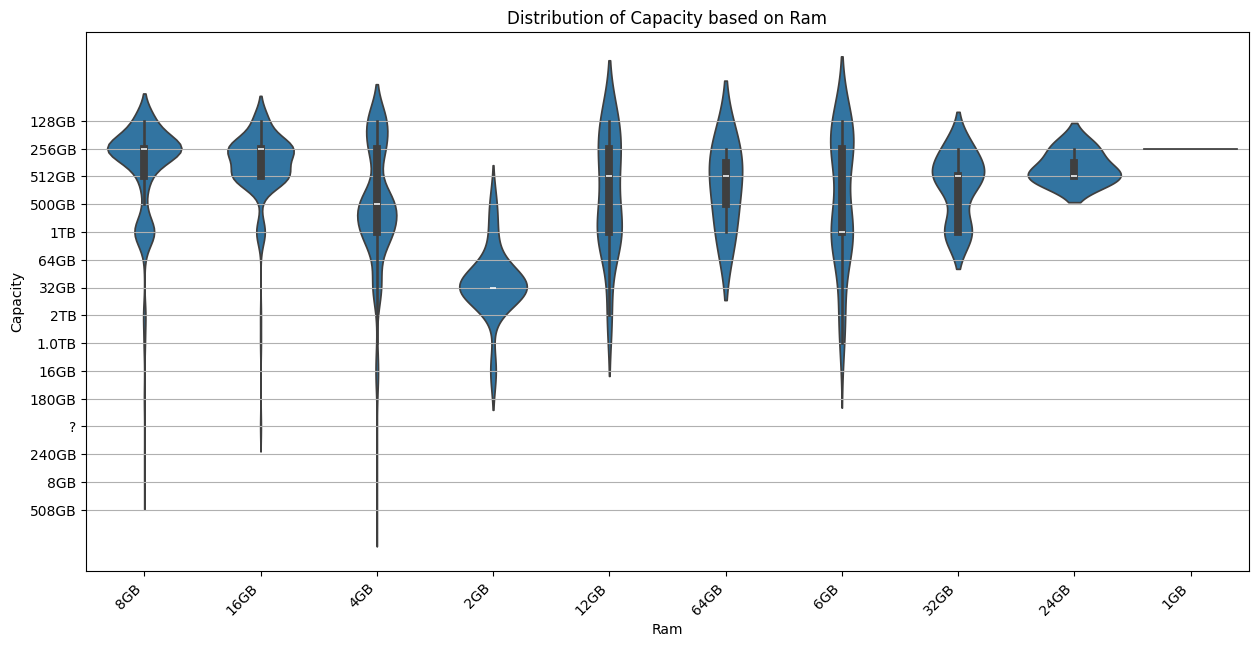

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 7))
sns.violinplot(x='Ram', y='Capacity', data=df5)
plt.title('Distribution of Capacity based on Ram')
plt.xlabel('Ram')
plt.ylabel('Capacity')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()